In [1]:
import numpy as np
from engram.patterns import (
    generate_sparse_pattern,
    corrupt_pattern,
    generate_cs_input,
)

rng = np.random.default_rng(42)

pattern = generate_sparse_pattern(n_neurons=2000, sparsity=0.1, rng=rng)
corrupted = corrupt_pattern(pattern, corruption_level=0.2, rng=rng)
cs_input = generate_cs_input(pattern, cue_fraction=0.5, rng=rng)

print("Pattern active neurons:", pattern.sum())
print("Corrupted active neurons:", corrupted.sum())
print("CS active neurons:", cs_input.sum())
print("CS overlap with pattern:", np.sum((cs_input == 1) & (pattern == 1)))

Pattern active neurons: 200
Corrupted active neurons: 512
CS active neurons: 100
CS overlap with pattern: 100


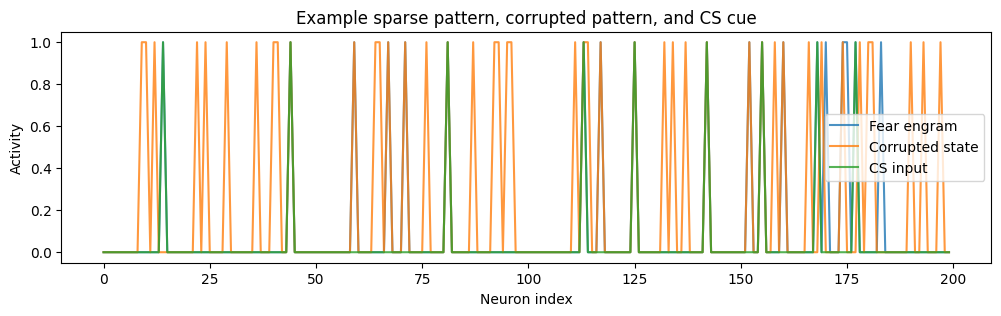

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(pattern[:200], label="Fear engram", alpha=0.8)
plt.plot(corrupted[:200], label="Corrupted state", alpha=0.8)
plt.plot(cs_input[:200], label="CS input", alpha=0.8)
plt.legend()
plt.xlabel("Neuron index")
plt.ylabel("Activity")
plt.title("Example sparse pattern, corrupted pattern, and CS cue")
plt.show()

In [3]:
from engram.hopfield import HopfieldNetwork

net = HopfieldNetwork(n_neurons=2000, sparsity=0.1)

net.store_patterns([pattern])

final_state, trajectory = net.run(
    initial_state=corrupted,
    external_input=cs_input,
    beta=1.0,
    theta=0.0,
)

print("Final active neurons:", final_state.sum())

Final active neurons: 200


In [5]:
overlap = np.sum((final_state == 1) & (pattern == 1)) / pattern.sum()

print("Overlap with fear engram:", overlap)

Overlap with fear engram: 1.0


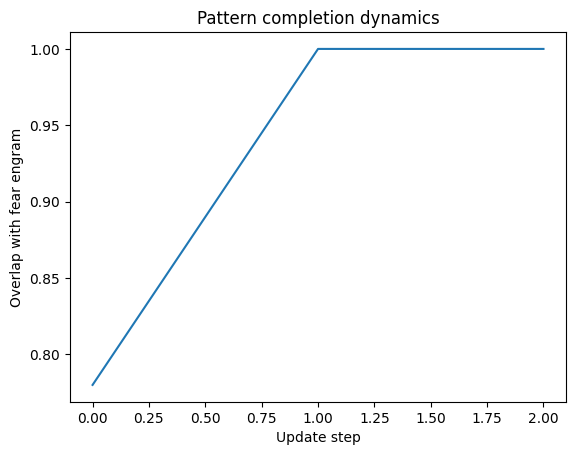

In [6]:
overlaps = []

for state in trajectory:
    ov = np.sum((state == 1) & (pattern == 1)) / pattern.sum()
    overlaps.append(ov)

import matplotlib.pyplot as plt

plt.plot(overlaps)
plt.xlabel("Update step")
plt.ylabel("Overlap with fear engram")
plt.title("Pattern completion dynamics")
plt.show()

In [7]:
from engram.metrics import pattern_overlap, retrieval_success

ov = pattern_overlap(final_state, pattern)
succ = retrieval_success(final_state, pattern, threshold=0.9)

print("Overlap:", ov)
print("Success:", succ)

Overlap: 1.0
Success: 1
